In [ ]:
import os, glob, re, random
import numpy as np
import matplotlib.pyplot as plt

from google.colab import drive
import pandas as pd
drive.mount('/content/drive')

# --- image processing ---
import cv2

# ========== Settings ==========
IMG_GLOB = "/content/drive/MyDrive/DATA/*.png" # Updated path to Google Drive
OUT_SIZE = 28
TRAIN_RATIO = 0.7
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

# ========== Helper: label mapping from SnapN.png ==========
def label_from_filename(path: str) -> int:
    """
    10-19   -> 1
    20-29  -> 2
    ...
    90-99 -> 9
    00-09 -> 0
    """
    base = os.path.basename(path)
    # Updated regex to match NN.png format (e.g., 00.png, 15.png)
    m = re.search(r"(\d{2})\.png$", base, re.IGNORECASE)
    if not m:
        # Updated error message to reflect the new expected format
        raise ValueError(f"檔名不符合 NN.png 格式: {base}")
    n = int(m.group(1)) # Extract the two-digit number

    # Implement the new mapping logic
    # The tens digit of n directly gives the label (00-09 -> 0, 10-19 -> 1, etc.)
    label = n // 10
    return label

# ========== Helper: preprocess to MNIST-like (28x28, white digit on black background) ==========
def preprocess_mnist_like(img_bgr: np.ndarray, out_size: int = 28) -> np.ndarray:
		## img_bgr → 輸入圖片 : np.ndarray → 型別是 NumPy array
               ## -> np.ndarray:  這個函式會回傳 numpy array
    """
    Steps:
    1) grayscale
    2) denoise/smooth (Gaussian blur)
    3) Otsu threshold to binary
    4) invert if needed so digit=white (255), background=black (0)
    5) find bounding box of digit, center it on a square canvas
    6) resize to (28,28)
    Output: uint8 image with values in {0,255}
    """
    # 1) gray
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

    # 2) smooth
    blur = cv2.GaussianBlur(gray, (5, 5), 0)

    # 3) Otsu binarize
    _, bin_img = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # 4) invert if needed:
    # want background mostly black, digit white.
    # If white pixels are more than half, likely background is white -> invert.
    white_ratio = (bin_img > 0).mean()
    if white_ratio > 0.5:
        bin_img = 255 - bin_img

    # 5) crop to digit bounding box (based on white pixels)
    coords = cv2.findNonZero(bin_img)  # non-zero are white digit pixels
    if coords is None:
        # totally blank? return black image
        return np.zeros((out_size, out_size), dtype=np.uint8)

    x, y, w, h = cv2.boundingRect(coords)
    digit = bin_img[y:y+h, x:x+w]

    # pad to square
    side = max(w, h)
    canvas = np.zeros((side, side), dtype=np.uint8)
    y_off = (side - h) // 2
    x_off = (side - w) // 2
    canvas[y_off:y_off+h, x_off:x_off+w] = digit

    # 6) resize to 28x28
    resized = cv2.resize(canvas, (out_size, out_size), interpolation=cv2.INTER_AREA)

    return resized.astype(np.uint8)

# ========== Load all images ==========
paths = sorted(glob.glob(IMG_GLOB))
   ##glob.glob(pattern) 會回傳 符合條件的檔案路徑列表 (list)。
   ## 'images/a.jpg', 'images/b.jpg', 'images/c.jpg'
if len(paths) == 0:
    raise FileNotFoundError(f"找不到任何 jpg: {IMG_GLOB}")

X = []
Y = []

for p in paths:
    img = cv2.imread(p)
    if img is None:
        print(f"讀不到圖檔，跳過: {p}")
        continue
    x = preprocess_mnist_like(img, OUT_SIZE)
    y = label_from_filename(p)
    X.append(x)
    Y.append(y)

X = np.stack(X, axis=0)          # (N, 28, 28)
Y = np.array(Y, dtype=np.int64)  # (N,)

print("Total samples:", len(X))
print("X shape:", X.shape, "dtype:", X.dtype, "range:", (X.min(), X.max()))
print("Y shape:", Y.shape, "labels:", sorted(set(Y.tolist())))

# ========== Train/Test split (random 70/30) ==========
idx = np.arange(len(X))
np.random.shuffle(idx)

split = int(len(X) * TRAIN_RATIO)
train_idx = idx[:split]
test_idx  = idx[split:]

x_train, y_train = X[train_idx], Y[train_idx]
x_test,  y_test  = X[test_idx],  Y[test_idx]

print("\nTrain:", x_train.shape, y_train.shape)
print("Test :", x_test.shape, y_test.shape)

Mounted at /content/drive
Total samples: 100
X shape: (100, 28, 28) dtype: uint8 range: (np.uint8(0), np.uint8(255))
Y shape: (100,) labels: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

Train: (70, 28, 28) (70,)
Test : (30, 28, 28) (30,)


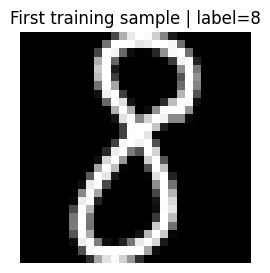

x_train[0,:,:] shape: (28, 28)


In [ ]:
# ========== Show first training example ==========
i = 0
plt.figure(figsize=(3,3))
plt.imshow(x_train[i], cmap='gray')
plt.title(f"First training sample | label={y_train[i]}")
plt.axis("off")
plt.show()

# verify indexing like MNIST:
print("x_train[0,:,:] shape:", x_train[0,:,:].shape)

[8 5 7 4 4]


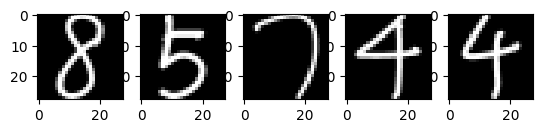

In [ ]:
for i in range(0,5):					##  劃出數字
    plt.subplot(1, 5, i+1)
    img = x_train[i]
    plt.imshow(img, cmap="gray")

##cmap: ~matplotlib.colors.Colormap，可選，默認值： 無
##如果沒有，默認為 rc image.cmap 值。 如果 X 具有 RGB(A) 信息，則忽略 cmap


print(y_train[:5])  ## show 出前5筆 y

In [ ]:
# add channel  開始為 CNN 準備  矩陣要變成 (資料筆數, 長, 寬, 黑白=1/彩色=3)
x_train = np.expand_dims(x_train, axis=3)
x_test = np.expand_dims(x_test, axis=3)
print(x_train.shape)
print(x_test.shape)
x_train_normalized = x_train / 255
x_test_normalized = x_test / 255


(70, 28, 28, 1, 1, 1)
(30, 28, 28, 1, 1, 1)


In [ ]:
import tensorflow.keras.utils as utils
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation, Flatten, Dropout, Conv2D, MaxPooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator

y_train_onehot = utils.to_categorical(y_train)  ## 轉成 10個0/1 碼

def show_train_history(train_history, train, validation):
    plt.plot(train_history.history[train])
    plt.plot(train_history.history[validation])
    plt.title("Train History")
    plt.ylabel(train)
    plt.xlabel('Epoch')
    plt.show()

model = Sequential()
model.add(Conv2D(16, (5,5), activation="relu", padding="same", data_format="channels_last", input_shape=(28,28,1)))
## channels_last 是指通道資料放在最後一維，channels_first 是指通道資料放在第二維，因第一維為樣本數。
model.add(MaxPooling2D(pool_size=(2,2), data_format="channels_last"))

model.add(Conv2D(36, (5,5), activation="relu", padding="same", data_format="channels_last"))
model.add(MaxPooling2D(pool_size=(2,2), data_format="channels_last"))

model.add(Flatten())
model.add(Dense(512, activation="relu"))
model.add(Dropout(0.5))
model.add(Dense(10, activation="softmax"))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 16)     │           416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 36)     │        14,436 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 36)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1764)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │       903,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 923,662 (3.52 MB)

 Trainable params: 923,662 (3.52 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.1607 - loss: 2.3186 - val_accuracy: 0.1429 - val_loss: 2.2662
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step - accuracy: 0.3750 - loss: 2.1441 - val_accuracy: 0.1429 - val_loss: 2.2687
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step - accuracy: 0.3571 - loss: 1.9869 - val_accuracy: 0.1429 - val_loss: 2.2880
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step - accuracy: 0.4464 - loss: 1.8703 - val_accuracy: 0.1429 - val_loss: 2.2591
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step - accuracy: 0.5357 - loss: 1.6582 - val_accuracy: 0.2143 - val_loss: 2.1449
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step - accuracy: 0.7500 - loss: 1.4156 - val_accuracy: 0.2143 - val_loss: 1.9830
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step - accuracy: 0.7500 - loss: 1.2781 - val_accuracy: 0.3571 - val_loss: 1.8261
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step - accuracy: 0.7500 - loss: 1.0633 - val_accuracy: 0.3571 - val_loss: 1.

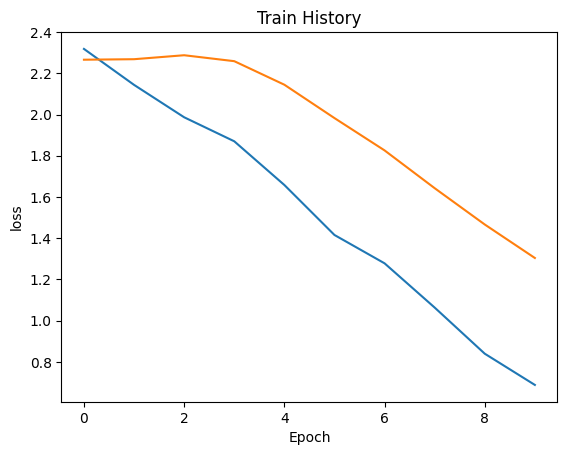

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 363ms/step - accuracy: 0.6000 - loss: 163.6731

Accuracy 0.6000000238418579%


In [ ]:
# 定義訓練方式
# loss function: 交叉熵
# optimizer: Adam
# 評估模型: 準確率
model.compile(loss='categorical_crossentropy', optimizer=Adam(), metrics=['accuracy'])

# Fix the shape issue here, as the input data has incorrect dimensions
# The model expects (None, 28, 28, 1) but received (None, 28, 28, 1, 1, 1)
# Reshape x_train_normalized to remove extra dimensions if they exist
if x_train_normalized.ndim > 4:
    x_train_normalized = x_train_normalized.reshape(x_train_normalized.shape[0], 28, 28, 1)

# Ensure x_test has the correct shape for evaluation
# Assuming x_test is also affected by multiple np.expand_dims calls
if x_test.ndim > 4:
    x_test = x_test.reshape(x_test.shape[0], 28, 28, 1)

# 開始訓練
train_history = model.fit(x_train_normalized, y_train_onehot, validation_split=0.2, epochs=10, batch_size=300, verbose=1)

show_train_history(train_history, 'loss', 'val_loss')

y_test_onehot = utils.to_categorical(y_test)

score = model.evaluate(x_test, y_test_onehot)
print()
print("Accuracy {}%".format(score[1]))